## Exercise 05.01.
Loading the Dataset (15-20 minutes) – In this exercise, you will begin by
loading the Star Wars dataset into a Pandas DataFrame . This is the first step in exploring
and analyzing data. Proper loading and inspection of the dataset are critical for understand-
ing its structure, identifying missing values, and preparing for further analysis. Working with
real-world datasets like this will help you develop the skills needed for effective data handling
in Python.

In [1]:
# Import the required libraries.
import pandas as pd

In [2]:
# Read Star Wars dataset into a dataframe
df = pd.read_csv("./exercises/starwars.csv")
print("Loaded dataset successfully")

Loaded dataset successfully


In [3]:
print("Preview of the first 5 rows of the DataFrame:")
df.head(10)  # Displays the first 10 rows

Preview of the first 5 rows of the DataFrame:


,name,height,mass,hair_color,skin_color,eye_color,birth_year,sex,gender,homeworld,species,films,vehicles,starships
0,Luke Skywalker,172.0,77.0,blond,fair,blue,19.0,male,masculine,Tatooine,Human,"A New Hope, The Empire Strikes Back, Return of...","Snowspeeder, Imperial Speeder Bike","X-wing, Imperial shuttle"
1,C-3PO,167.0,75.0,NaN,gold,yellow,112.0,none,masculine,Tatooine,Droid,"A New Hope, The Empire Strikes Back, Return of...",NaN,NaN
2,R2-D2,96.0,32.0,NaN,"white, blue",red,33.0,none,masculine,Naboo,Droid,"A New Hope, The Empire Strikes Back, Return of...",NaN,NaN
3,Darth Vader,202.0,136.0,none,white,yellow,41.9,male,masculine,Tatooine,Human,"A New Hope, The Empire Strikes Back, Return of...",NaN,TIE Advanced x1
4,Leia Organa,150.0,49.0,brown,light,brown,19.0,female,feminine,Alderaan,Human,"A New Hope, The Empire Strikes Back, Return of...",Imperial Speeder Bike,NaN
5,Owen Lars,178.0,120.0,"brown, grey",light,blue,52.0,male,masculine,Tatooine,Human,"A New Hope, Attack of the Clones, Revenge of t...",NaN,NaN
6,Beru Whitesun Lars,165.0,75.0,brown,light,blue,47.0,female,feminine,Tatooine,Human,"A New Hope, Attack of the Clones, Revenge of t...",NaN,NaN
7,R5-D4,97.0,32.0,NaN,"white, red",red,NaN,none,masculine,Tatooine,Droid,A New Hope,NaN,NaN
8,Biggs Darklighter,183.0,84.0,black,light,brown,24.0,male,masculine,Tatooine,Human,A New Hope,NaN,X-wing
9,Obi-Wan Kenobi,182.0,77.0,"auburn, white",fair,blue-gray,57.0,male,masculine,Stewjon,Human,"A New Hope, The Empire Strikes Back, Return of...",Tribubble bongo,"Jedi starfighter, Trade Federation cruiser, Na..."


In [4]:
print("\nPreview of the last 10 rows of the DataFrame:")
df.tail()  # Displays the last 10 rows


Preview of the last 10 rows of the DataFrame:


,name,height,mass,hair_color,skin_color,eye_color,birth_year,sex,gender,homeworld,species,films,vehicles,starships
82,Finn,NaN,NaN,black,dark,dark,NaN,male,masculine,NaN,Human,The Force Awakens,NaN,NaN
83,Rey,NaN,NaN,brown,light,hazel,NaN,female,feminine,NaN,Human,The Force Awakens,NaN,NaN
84,Poe Dameron,NaN,NaN,brown,light,brown,NaN,male,masculine,NaN,Human,The Force Awakens,NaN,X-wing
85,BB8,NaN,NaN,none,none,black,NaN,none,masculine,NaN,Droid,The Force Awakens,NaN,NaN
86,Captain Phasma,NaN,NaN,none,none,unknown,NaN,female,feminine,NaN,Human,The Force Awakens,NaN,NaN


In [27]:
# Inspect the structure of the dataframe
print("Shape (rows, cols):", df.shape)
df.info()          # column names, dtypes, and non-null counts in one view
df.isna().sum()    # explicit missing-value count per column

Shape (rows, cols): (87, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        87 non-null     object 
 1   height      81 non-null     float64
 2   mass        59 non-null     float64
 3   hair_color  82 non-null     object 
 4   skin_color  87 non-null     object 
 5   eye_color   87 non-null     object 
 6   birth_year  43 non-null     float64
 7   sex         83 non-null     object 
 8   gender      83 non-null     object 
 9   homeworld   77 non-null     object 
 10  species     83 non-null     object 
 11  films       87 non-null     object 
 12  vehicles    11 non-null     object 
 13  starships   20 non-null     object 
dtypes: float64(3), object(11)
memory usage: 9.6+ KB


name           0
height         6
mass          28
hair_color     5
skin_color     0
eye_color      0
birth_year    44
sex            4
gender         4
homeworld     10
species        4
films          0
vehicles      76
starships     67
dtype: int64

In [5]:
# Handling missing data

# Numeric columns -> fill with that column's mean
num_cols = df.select_dtypes(include="number").columns
for c in num_cols:
    df[c] = df[c].fillna(df[c].mean())

# Categorical (non-numeric) columns -> fill with "Unknown"
cat_cols = df.select_dtypes(exclude="number").columns
for c in cat_cols:
    df[c] = df[c].fillna("Unknown")

print("Remaining missing values:", df.isna().sum().sum())   # -> 0
df.isna().sum()

Remaining missing values: 0


name          0
height        0
mass          0
hair_color    0
skin_color    0
eye_color     0
birth_year    0
sex           0
gender        0
homeworld     0
species       0
films         0
vehicles      0
starships     0
dtype: int64

Ten columns contained missing values. I imputed them by type rather than
dropping any rows, so the dataset stayed at its original 87 rows × 14 columns.

- Numeric columns (`height`, `mass`, `birth_year`): each gap filled with the
  column's mean via `fillna(df[c].mean())`.
- Categorical columns (`hair_color`, `sex`, `gender`, `homeworld`, `species`,
  `vehicles`, `starships`): filled with the string `"Unknown"`.

`df.isna().sum().sum()` returns 0 afterwards, confirming no missing values
remain. Only cell values changed — the shape (87 × 14) is unchanged, since I
imputed rather than removed data.

Two caveats:
- `birth_year` was missing in 44 of 87 rows (over half). Filling that many gaps
  with the mean collapses most of the column onto one value, so its distribution
  after cleaning is largely an artifact of the imputation and shouldn't be
  over-trusted.
- The blanks in `vehicles` and `starships` don't really mean "unknown" — they
  mean the character uses none. `"Unknown"` is a slight misnomer here; `"None"`
  would describe the data more honestly.

## The tables below show the first 10 and last 10 rows of the cleaned dataset. Previously-empty numeric cells now hold the column mean, and previously-empty categorical cells now read "Unknown".

In [32]:
# Dataset — before/after preview
print("First 10 rows:")
df.head(10)

First 10 rows:


,name,height,mass,hair_color,skin_color,eye_color,birth_year,sex,gender,homeworld,species,films,vehicles,starships
0,Luke Skywalker,172.0,77.0,blond,fair,blue,19.000000,male,masculine,Tatooine,Human,"A New Hope, The Empire Strikes Back, Return of...","Snowspeeder, Imperial Speeder Bike","X-wing, Imperial shuttle"
1,C-3PO,167.0,75.0,Unknown,gold,yellow,112.000000,none,masculine,Tatooine,Droid,"A New Hope, The Empire Strikes Back, Return of...",Unknown,Unknown
2,R2-D2,96.0,32.0,Unknown,"white, blue",red,33.000000,none,masculine,Naboo,Droid,"A New Hope, The Empire Strikes Back, Return of...",Unknown,Unknown
3,Darth Vader,202.0,136.0,none,white,yellow,41.900000,male,masculine,Tatooine,Human,"A New Hope, The Empire Strikes Back, Return of...",Unknown,TIE Advanced x1
4,Leia Organa,150.0,49.0,brown,light,brown,19.000000,female,feminine,Alderaan,Human,"A New Hope, The Empire Strikes Back, Return of...",Imperial Speeder Bike,Unknown
5,Owen Lars,178.0,120.0,"brown, grey",light,blue,52.000000,male,masculine,Tatooine,Human,"A New Hope, Attack of the Clones, Revenge of t...",Unknown,Unknown
6,Beru Whitesun Lars,165.0,75.0,brown,light,blue,47.000000,female,feminine,Tatooine,Human,"A New Hope, Attack of the Clones, Revenge of t...",Unknown,Unknown
7,R5-D4,97.0,32.0,Unknown,"white, red",red,87.565116,none,masculine,Tatooine,Droid,A New Hope,Unknown,Unknown
8,Biggs Darklighter,183.0,84.0,black,light,brown,24.000000,male,masculine,Tatooine,Human,A New Hope,Unknown,X-wing
9,Obi-Wan Kenobi,182.0,77.0,"auburn, white",fair,blue-gray,57.000000,male,masculine,Stewjon,Human,"A New Hope, The Empire Strikes Back, Return of...",Tribubble bongo,"Jedi starfighter, Trade Federation cruiser, Na..."


In [31]:
print("Last 10 rows:")
df.tail(10)

Last 10 rows:


,name,height,mass,hair_color,skin_color,eye_color,birth_year,sex,gender,homeworld,species,films,vehicles,starships
77,Grievous,216.000000,159.000000,none,"brown, white","green, yellow",87.565116,male,masculine,Kalee,Kaleesh,Revenge of the Sith,Tsmeu-6 personal wheel bike,Belbullab-22 starfighter
78,Tarfful,234.000000,136.000000,brown,brown,blue,87.565116,male,masculine,Kashyyyk,Wookiee,Revenge of the Sith,Unknown,Unknown
79,Raymus Antilles,188.000000,79.000000,brown,light,brown,87.565116,male,masculine,Alderaan,Human,"A New Hope, Revenge of the Sith",Unknown,Unknown
80,Sly Moore,178.000000,48.000000,none,pale,white,87.565116,Unknown,Unknown,Umbara,Unknown,"Attack of the Clones, Revenge of the Sith",Unknown,Unknown
81,Tion Medon,206.000000,80.000000,none,grey,black,87.565116,male,masculine,Utapau,Pau'an,Revenge of the Sith,Unknown,Unknown
82,Finn,174.604938,97.311864,black,dark,dark,87.565116,male,masculine,Unknown,Human,The Force Awakens,Unknown,Unknown
83,Rey,174.604938,97.311864,brown,light,hazel,87.565116,female,feminine,Unknown,Human,The Force Awakens,Unknown,Unknown
84,Poe Dameron,174.604938,97.311864,brown,light,brown,87.565116,male,masculine,Unknown,Human,The Force Awakens,Unknown,X-wing
85,BB8,174.604938,97.311864,none,none,black,87.565116,none,masculine,Unknown,Droid,The Force Awakens,Unknown,Unknown
86,Captain Phasma,174.604938,97.311864,none,none,unknown,87.565116,female,feminine,Unknown,Human,The Force Awakens,Unknown,Unknown


## Exercise 05.02. (Assignment #01)
Descriptive Statistics (20-30 minutes) –
In this exercise, you will compute descriptive statistics for the Star Wars dataset to summarize its main
characteristics. Descriptive statistics help you understand the data’s distribution, central
tendency, and variability. By analyzing the numeric columns, such as character height and
mass , you will gain insights into the dataset and identify any potential outliers. This task
will prepare you for more in-depth data analysis and exploration.

In [6]:
raw = pd.read_csv("./exercises/starwars.csv")   # original, before imputation
cols = ["height", "mass", "birth_year"]          # the three numeric columns

summary = raw[cols].agg(["mean", "median", "std", "var"]).T
summary["mode"] = raw[cols].mode().iloc[0]       # first mode of each column
summary

,mean,median,std,var,mode
height,174.604938,180.0,34.774157,1209.241975,183.0
mass,97.311864,79.0,169.457163,28715.730029,80.0
birth_year,87.565116,52.0,154.691439,23929.441373,19.0


# Q1 — descriptive statistics
I selected the three numeric columns: `height`, `mass`, and `birth_year`.
Statistics were computed on the original data (before the 05.01 imputation),
since pandas skips missing values automatically and this avoids biasing the
results.

| Column     | Mean   | Median | Mode          | Std Dev | Variance  |
|------------|--------|--------|---------------|---------|-----------|
| height     | 174.60 | 180.00 | 183           | 34.77   | 1,209.24  |
| mass       | 97.31  | 79.00  | 80            | 169.46  | 28,715.73 |
| birth_year | 87.57  | 52.00  | 19 / 41.9 / 48| 154.69  | 23,929.44 |

`birth_year` is multimodal (three values tie), so its mode carries little meaning.

## Q2 — mean vs median
- height: mean (174.6) sits slightly below the median (180), a mild left skew.
  A cluster of short characters (droids, Yoda) drags the mean down.
- mass: mean (97.3) is far above the median (79), a strong right skew, driven
  almost entirely by Jabba the Hutt (1358 kg).
- birth_year: mean (87.6) is well above the median (52), again a strong right
  skew, caused by a few very old characters (Yoda 896, Jabba 600).

Rule of thumb: mean > median indicates right skew, mean < median indicates left
skew. Where the data is skewed, the median is the more trustworthy measure of
the "typical" value.

# Q3 — highest variability
By raw standard deviation and variance, `mass` is the most variable
(std 169.5, var 28,716), just ahead of `birth_year` (std 154.7, var 23,929);
`height` is far tighter (std 34.8).

Caveat: std and variance are scale-dependent, so comparing across columns with
different units (cm, kg, years) isn't strictly fair. Normalising by the mean
(coefficient of variation = std/mean) gives height ≈ 0.20, mass ≈ 1.74,
birth_year ≈ 1.77 — so relative to their own scale, mass and birth_year are
comparably dispersed and both far more variable than height.

# Q4 — outliers
- mass: Jabba the Hutt at 1358 kg is an extreme outlier — over 7x the median.
- birth_year: Yoda (896) and Jabba (600) sit far above the ~52-year median.
- height: Yarael Poof (264 cm) is a clear high outlier; the very short
  characters (Yoda 66, R2-D2 96) are genuine small droids/species, not errors.

Method note: I flagged values beyond mean ± 2 standard deviations. For `mass`
this is imperfect — Jabba's value so inflates the standard deviation that the
2σ band only catches Jabba himself (the outlier masks its own detection). An
IQR-based rule (below Q1 − 1.5·IQR or above Q3 + 1.5·IQR) is more robust and
would flag the same extreme cases without that distortion.

# Missing-values effect (the sub-point, and the reason for computing on original data)
Statistics were computed on the pre-imputation data. Had I used the 05.01
dataframe, where numeric gaps were filled with the column mean, the results
would be misleading:
- the mean is unchanged (mean-filling preserves it by construction);
- the variance and std shrink — e.g. birth_year variance falls from ~23,929 to
  ~11,686 (roughly halved) — because every filled value sits exactly on the mean
  and adds no spread;
- the median is pulled toward the mean (birth_year median jumps 52 -> 87.6);
- the mode becomes the fill value itself (87.6).

Because `birth_year` and `mass` were 30-50%+ missing, imputing with the mean and
then measuring spread or shape would badly understate their true variability.
This is why descriptive statistics here are best taken from the original values.

## Exercise 05.04. (Assignment #01)
Categorical Data Exploration (30-35 minutes) – In this
exercise, you will explore the categorical variables in the Star Wars dataset. Categorical data
exploration helps you understand how different categories are distributed within the dataset
and whether any notable patterns exist between them. Visualizing the relationship between
these variables allows you to uncover exciting trends and better understand the dataset’s
structure. This task will give you experience in analyzing and visualizing categorical data.

In [7]:
# Import the required libraries.
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# Read Star Wars dataset into a dataframe
df = pd.read_csv("./exercises/starwars.csv")
print("Loaded dataset successfully")

Loaded dataset successfully


In [9]:
# Clean the dataset
df['species'] = df['species'].fillna('Unknown')
df['gender'] = df['gender'].fillna('Unknown')

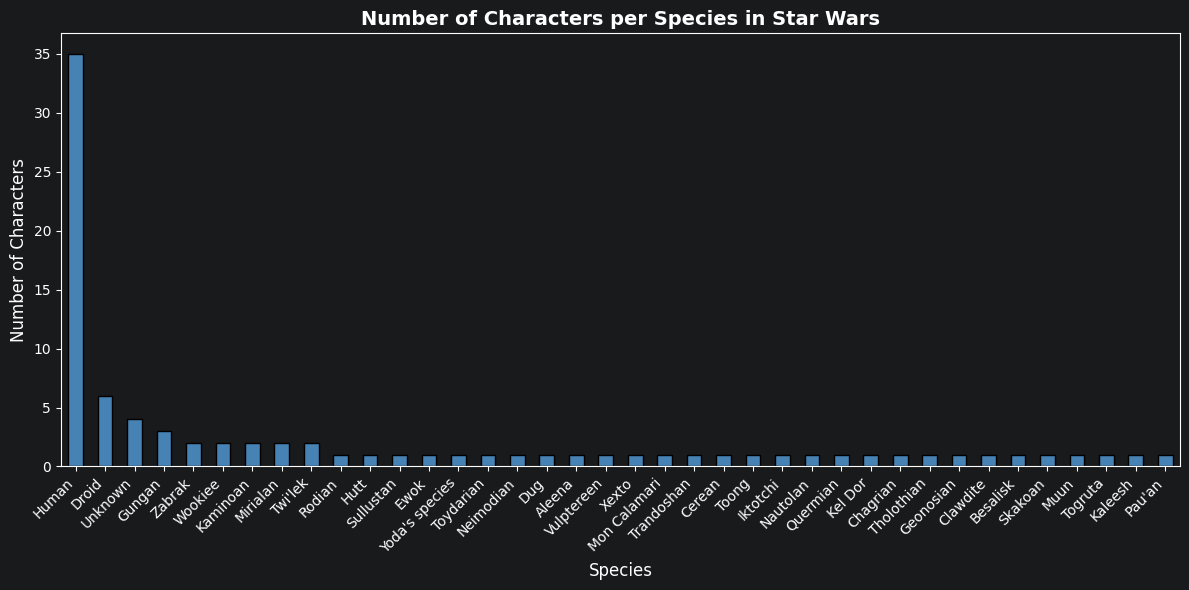

In [10]:
# Bar chart
species_counts = df['species'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
species_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Number of Characters per Species in Star Wars', fontsize=14, fontweight='bold')
ax.set_xlabel('Species', fontsize=12)
ax.set_ylabel('Number of Characters', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('species_count.png', dpi=150)
plt.show()

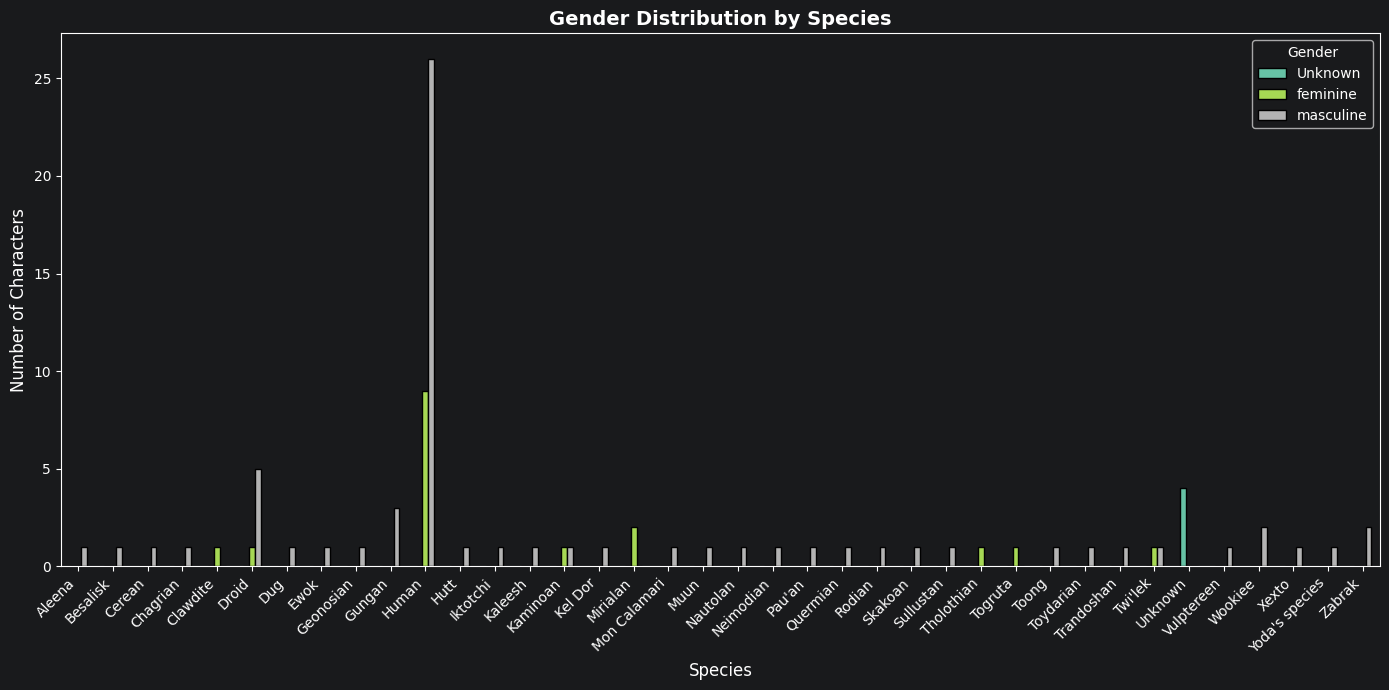

In [11]:
# 2. Grouped bar chart
grouped = df.groupby(['species', 'gender']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))
grouped.plot(kind='bar', ax=ax, edgecolor='black', colormap='Set2')
ax.set_title('Gender Distribution by Species', fontsize=14, fontweight='bold')
ax.set_xlabel('Species', fontsize=12)
ax.set_ylabel('Number of Characters', fontsize=12)
ax.legend(title='Gender')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('gender_by_species.png', dpi=150)
plt.show()

In [12]:
# Analysis
print("Most common species:", species_counts.idxmax(), "-", species_counts.max(), "characters")
print("\nGender breakdown of most populous species:")
top_species = species_counts.idxmax()
print(df[df['species'] == top_species]['gender'].value_counts())

Most common species: Human - 35 characters

Gender breakdown of most populous species:
gender
masculine    26
feminine      9
Name: count, dtype: int64


# Exercise 05.04 — Categorical Data Exploration (Star Wars)

## Approach
I loaded the dataset with pandas and filled missing `species` / `gender`
values with `"Unknown"` so nothing silently gets dropped. Then I built a
bar chart of character counts per species with `value_counts()`, and a
grouped bar chart of gender-by-species using
`groupby(['species','gender']).size().unstack(fill_value=0)`, sorted by
total count so the chart reads top-down.

## Expected outputs/questions

### 1. Which species has the most characters?
Humans, around 35 characters. The next species,
Droid, only has about 6. So the dataset is heavily Human-dominated, and
everything else is a long tail.

### 2. How does gender distribution vary across species? Which show an imbalanced ratio?
Humans are basically the only species with a real gender mix, and even
they lean male (roughly 26 male to 9 female). Droids come out as mostly
`none` / masculine-coded. For every other species I can't really talk
about a "ratio". Most of them only have 1–2 characters, so any imbalance
is just an artifact of the tiny sample, not a real pattern. The one case
where an imbalance is actually meaningful is Humans, because that's the
only group with enough data to say anything.

### 3. Any underrepresented species or gender categories?
Female characters are underrepresented overall — only about 19 out of 87.
And nearly every non-Human species is underrepresented too, since most
show up just once. On the gender side, `hermaphroditic` and `none` / `n/a`
are edge cases.


## Exercise 05.06. (Assignment #01)
Interactive Visualization and Exploratory Data Anal-
ysis (30-45 minutes) In this exercise, you will combine interactive visualization techniques
with automated exploratory data analysis (EDA) to gain comprehensive insights into the Star
Wars dataset. Using tools like Plotly for interactive visualizations and ydata profiling for
automated profiling, you will explore data patterns, identify correlations, spot potential is-
sues, and interact with the data dynamically. This exercise gives you hands-on experience
with advanced data exploration techniques, helping you build intuitive visualizations and
gain deep insights into the dataset.

In [13]:
import pandas as pd
import plotly.express as px
from ydata_profiling import ProfileReport

df = pd.read_csv("./exercises/starwars.csv")

df['species'] = df['species'].fillna('Unknown')
df['gender'] = df['gender'].fillna('Unknown')

# 1. Automated EDA report
profile = ProfileReport(df, title='Star Wars EDA Report', explorative=True)
profile.to_file('starwars_eda_report.html')

# 2. Interactive scatter: height vs mass
# height/mass are often read as strings/objects in this dataset — coerce them
df['height'] = pd.to_numeric(df['height'], errors='coerce')
df['mass']   = pd.to_numeric(df['mass'], errors='coerce')

fig_scatter = px.scatter(
    df, x='height', y='mass', color='species',
    hover_name='name',
    hover_data=['species', 'gender'],
    title='Height vs Mass by Species',
    labels={'height': 'Height (cm)', 'mass': 'Mass (kg)'}
)
fig_scatter.write_html('scatter_height_mass.html')
fig_scatter.show()

# 3. Interactive bar: species distribution
species_counts = df['species'].value_counts().reset_index()
species_counts.columns = ['species', 'count']

fig_bar = px.bar(
    species_counts, x='species', y='count',
    title='Character Count per Species',
    labels={'species': 'Species', 'count': 'Number of Characters'},
    hover_data={'count': True}
)
fig_bar.write_html('species_bar.html')
fig_bar.show()

C:\Users\david\miniforge3\envs\damml2026\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\david\AppData\Local\Temp\ipykernel_28284\2024155868.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 177.98it/s]
